# 3CSD Group 8 Implementation

**Evaluating Algorithmic Bias and Feature Thresholds in Predicting Geopolitical Attack Success Using Logistic Regression, XGBoost, and a Feedforward Neural Network on the Global Terrorism Database**

This notebook is the main manuscript-facing implementation. It keeps the code concise by using reusable helpers from `src/gtd_pipeline.py` while still implementing the complete proposal:

- Logistic Regression baseline
- Extreme Gradient Boosting / XGBoost SOTA tabular model
- Feedforward Neural Network
- SHAP/feature importance and coefficient interpretation
- threshold simulations
- subgroup error disparity analysis
- leakage/assumption sensitivity checks

Raw data must be real GTD data, not synthetic data. The canonical location is `data/raw/`.

## 1. Setup and Reproducibility

The notebook can be run from the project root or from `notebooks/`. The 2021 supplement is mandatory because the GTD provider distributes it separately.

Caching note: the first full run reads the Excel workbooks and writes `data/processed/gtd_combined_cleaned.parquet`. Later runs load this cache, avoiding repeated slow Excel parsing. Set `REBUILD_DATA_CACHE = True` only when the raw files change.

In [ ]:
from pathlib import Path
import random
import sys

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.gtd_pipeline import *

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

USE_SAMPLE = False          # True = quick smoke test, False = final manuscript run.
SAMPLE_NROWS = 5000
REBUILD_DATA_CACHE = False  # True only if raw files changed.
USE_GPU = True
RUN_SHAP = True             # XGBoost stuff
SHAP_SAMPLE_SIZE = 1500

paths = get_project_paths(PROJECT_ROOT)
print("Project root:", paths.root)
print("Raw data directory:", paths.raw_dir)
print("Main GTD file:", paths.main_file)
print("Mandatory 2021 supplement:", paths.supplement_2021_file)
print("Processed cache:", paths.cache_file)

Project root: c:\Documents\Compsci\CSELEC2C\Project
Raw data directory: c:\Documents\Compsci\CSELEC2C\Project\data\raw
Main GTD file: c:\Documents\Compsci\CSELEC2C\Project\data\raw\globalterrorismdb_0522dist.xlsx
Mandatory 2021 supplement: c:\Documents\Compsci\CSELEC2C\Project\data\raw\globalterrorismdb_2021Jan-June_1222dist.xlsx
Processed cache: c:\Documents\Compsci\CSELEC2C\Project\data\processed\gtd_combined_cleaned.parquet


## 2. Modeling Assumptions and Feature Set

The target is GTD `success`. To reduce target leakage, casualty, property-damage, ransom, and hostage-outcome fields are excluded because they are consequences or post-event descriptors. The retained features are temporal, geopolitical, tactical, target, weapon, uncertainty, and claim-related fields.

In [29]:
print("Target:", TARGET)
print("Numeric features:", NUMERIC_FEATURES)
print("Categorical features:", CATEGORICAL_FEATURES)
print("Excluded leakage columns:", LEAKAGE_COLUMNS_EXCLUDED)

Target: success
Numeric features: ['iyear', 'imonth', 'iday', 'extended', 'latitude', 'longitude', 'specificity', 'vicinity', 'doubtterr', 'multiple', 'suicide', 'guncertain1', 'individual', 'claimed', 'INT_LOG', 'INT_IDEO', 'INT_MISC', 'INT_ANY']
Categorical features: ['region_txt', 'country_txt', 'attacktype1_txt', 'targtype1_txt', 'targsubtype1_txt', 'natlty1_txt', 'weaptype1_txt', 'weapsubtype1_txt']
Excluded leakage columns: ['nkill', 'nkillus', 'nkillter', 'nwound', 'nwoundus', 'nwoundte', 'property', 'propextent', 'propextent_txt', 'propvalue', 'ransom', 'ransomamt', 'ransompaid', 'hostkidoutcome', 'hostkidoutcome_txt', 'nreleased']


## 3. Load, Clean, Cache, and Split Data

Both GTD files are mandatory. The main file and the 2021 supplement are combined, deduplicated by `eventid`, cleaned, then split temporally:

- Train: 1970–2014
- Validation: 2015–2017
- Test: 2018 onward

In [30]:
sample_nrows = SAMPLE_NROWS if USE_SAMPLE else None
if REBUILD_DATA_CACHE and paths.cache_file.exists():
    paths.cache_file.unlink()

df = load_gtd(paths, use_cache=not REBUILD_DATA_CACHE, sample_nrows=sample_nrows)
X, y, numeric_features, categorical_features = make_xy(df)
X_train, X_valid, X_test, y_train, y_valid, y_test = temporal_split(X, y)

split_summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "n": [len(X_train), len(X_valid), len(X_test)],
    "start_year": [int(X_train.iyear.min()), int(X_valid.iyear.min()), int(X_test.iyear.min())],
    "end_year": [int(X_train.iyear.max()), int(X_valid.iyear.max()), int(X_test.iyear.max())],
    "success_rate": [y_train.mean(), y_valid.mean(), y_test.mean()],
})

class_balance = y.value_counts(normalize=True).rename("proportion").to_frame()
class_balance["count"] = y.value_counts()

print("Raw/cleaned shape:", df.shape)
print("Year range:", int(df.iyear.min()), "to", int(df.iyear.max()))
display(split_summary)
display(class_balance)

Raw/cleaned shape: (214666, 29)
Year range: 1970 to 2021


,split,n,start_year,end_year,success_rate
0,train,142325,1970,2014,0.909229
1,validation,40553,2015,2017,0.818706
2,test,31788,2018,2021,0.846829


,proportion,count
success,,
1,0.882888,189526
0,0.117112,25140


## 4. Train Proposal Models

The model lineup follows the proposal exactly: Logistic Regression as the baseline, XGBoost as the SOTA tabular model, and a Feedforward Neural Network as a nonlinear architecture.

In [31]:
models = build_models(numeric_features, categorical_features, y_train, use_gpu=USE_GPU, random_state=RANDOM_STATE)
models = train_models(models, X_train, y_train, paths)
print("Trained models:", list(models))

Training logistic_regression...
Training xgboost...
Training feedforward_torch_nn...
Torch NN epoch 01 | train_loss=0.1009 | valid_loss=0.0935
Torch NN epoch 05 | train_loss=0.0847 | valid_loss=0.0888
Torch NN epoch 10 | train_loss=0.0769 | valid_loss=0.0916
Trained models: ['logistic_regression', 'xgboost', 'feedforward_torch_nn']


## 5. Main Evaluation Metrics

We report ranking metrics, threshold metrics, minority/failure-class AP, and calibration-sensitive Brier score. Accuracy alone is not emphasized because `success=1` is the majority class.

In [32]:
metrics_df = evaluate_models(models, X_valid, y_valid, X_test, y_test)
save_table(metrics_df, paths.tables_dir / "model_metrics.csv")
display(metrics_df)

,model,split,roc_auc,average_precision_success,average_precision_failure,brier_score,threshold,accuracy,balanced_accuracy,precision,recall,f1,false_positive_rate,false_negative_rate,tp,fp,tn,fn,mcc
0,logistic_regression,validation,0.780362,0.931936,0.530547,0.175461,0.5,0.751313,0.708813,0.907287,0.775489,0.836227,0.357862,0.224511,25747,2631,4721,7454,0.351028
1,xgboost,validation,0.796981,0.939900,0.567509,0.161846,0.5,0.774419,0.717312,0.907305,0.806903,0.854164,0.372280,0.193097,26790,2737,4615,6411,0.376334
2,feedforward_torch_nn,validation,0.834543,0.952347,0.594059,0.168607,0.5,0.753680,0.744835,0.927194,0.758712,0.834534,0.269042,0.241288,25190,1978,5374,8011,0.401184
3,logistic_regression,test,0.769711,0.943835,0.455160,0.181485,0.5,0.748364,0.692024,0.916557,0.773246,0.838824,0.389197,0.226754,20815,1895,2974,6104,0.306219
4,xgboost,test,0.779661,0.947605,0.478004,0.162394,0.5,0.781427,0.693966,0.912982,0.820053,0.864026,0.432122,0.179947,22075,2104,2765,4844,0.327432
5,feedforward_torch_nn,test,0.802758,0.950708,0.491865,0.191790,0.5,0.723166,0.725850,0.936581,0.721981,0.815398,0.270281,0.278019,19435,1316,3553,7484,0.341707


## 6. Threshold Simulation and Validation-Selected Thresholds

The default 0.50 threshold is not neutral. We simulate multiple thresholds and also select each model's threshold on validation balanced accuracy before evaluating once on the test set.

In [33]:
threshold_df = threshold_simulation(models, X_test, y_test)
save_table(threshold_df, paths.tables_dir / "threshold_simulation_results.csv")

selected_threshold_df = select_validation_thresholds(models, X_valid, y_valid, X_test, y_test)
save_table(selected_threshold_df, paths.tables_dir / "proposal_validation_selected_thresholds.csv")

display(threshold_df)
display(selected_threshold_df)

,model,split,threshold,accuracy,balanced_accuracy,precision,recall,f1,false_positive_rate,false_negative_rate,tp,fp,tn,fn
0,logistic_regression,test,0.3,0.831666,0.680645,0.902418,0.898362,0.900385,0.537071,0.101638,24183,2615,2254,2736
1,logistic_regression,test,0.4,0.797691,0.690530,0.909662,0.845017,0.876148,0.463956,0.154983,22747,2259,2610,4172
2,logistic_regression,test,0.5,0.748364,0.692024,0.916557,0.773246,0.838824,0.389197,0.226754,20815,1895,2974,6104
3,logistic_regression,test,0.6,0.664276,0.687293,0.928251,0.654110,0.767434,0.279524,0.345890,17608,1361,3508,9311
4,logistic_regression,test,0.7,0.532213,0.655246,0.940420,0.477878,0.633726,0.167386,0.522122,12864,815,4054,14055
5,xgboost,test,0.3,0.845759,0.681144,0.901283,0.918459,0.909790,0.556172,0.081541,24724,2708,2161,2195
6,xgboost,test,0.4,0.822984,0.692594,0.907643,0.880568,0.893900,0.495379,0.119432,23704,2412,2457,3215
7,xgboost,test,0.5,0.781427,0.693966,0.912982,0.820053,0.864026,0.432122,0.179947,22075,2104,2765,4844
8,xgboost,test,0.6,0.714043,0.689424,0.920515,0.724915,0.811089,0.346067,0.275085,19514,1685,3184,7405
9,xgboost,test,0.7,0.595225,0.675291,0.936669,0.559865,0.700830,0.209283,0.440135,15071,1019,3850,11848


,model,split,threshold,accuracy,balanced_accuracy,precision,recall,f1,false_positive_rate,false_negative_rate,tp,fp,tn,fn
0,logistic_regression,validation,0.40,0.803788,0.713804,0.900343,0.854974,0.877072,0.427367,0.145026,28386,3142,4210,4815
1,logistic_regression,test_selected_validation_threshold,0.40,0.797691,0.690530,0.909662,0.845017,0.876148,0.463956,0.154983,22747,2259,2610,4172
2,xgboost,validation,0.46,0.794910,0.719819,0.904802,0.837625,0.869919,0.397987,0.162375,27810,2926,4426,5391
3,xgboost,test_selected_validation_threshold,0.46,0.798698,0.694405,0.911058,0.844756,0.876655,0.455946,0.155244,22740,2220,2649,4179
4,feedforward_torch_nn,validation,0.46,0.767465,0.745787,0.924346,0.779796,0.845940,0.288221,0.220204,25890,2119,5233,7311
5,feedforward_torch_nn,test_selected_validation_threshold,0.46,0.739052,0.726902,0.934045,0.744418,0.828520,0.290614,0.255582,20039,1415,3454,6880


## 7. Curves and Overfitting Check for XGBoost

The XGBoost learning curve checks whether validation performance deteriorates as boosting rounds continue.

Best validation PR-AUC iteration: 344
Final train-validation PR-AUC gap: 0.04074503187516132


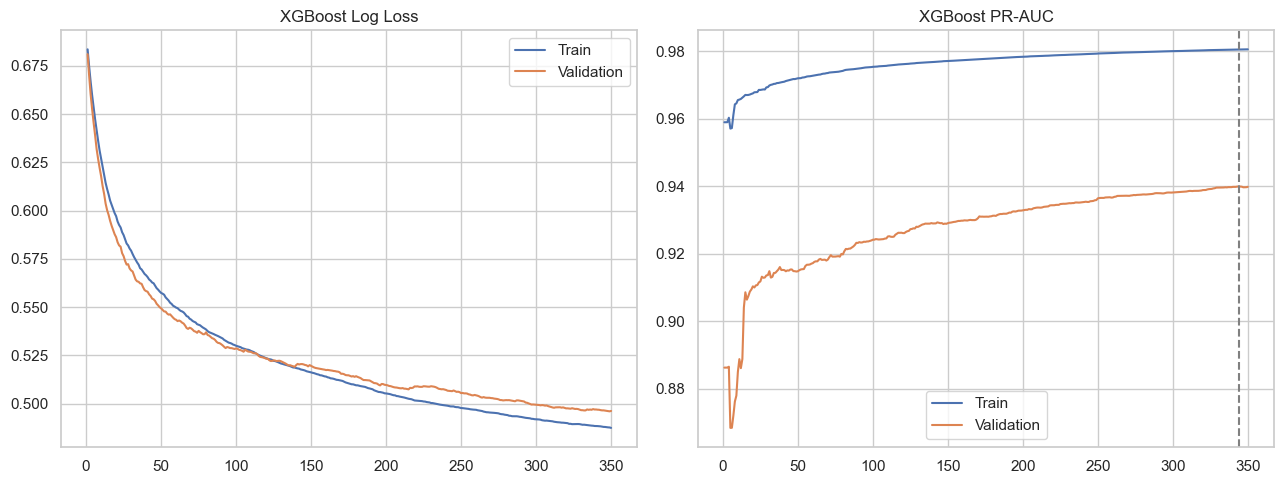

,iteration,train_logloss,valid_logloss,train_aucpr,valid_aucpr
345,346,0.487948,0.496408,0.980584,0.939925
346,347,0.487818,0.496292,0.980607,0.939747
347,348,0.487736,0.496178,0.980610,0.939767
348,349,0.487687,0.496037,0.980617,0.939779
349,350,0.487471,0.496239,0.980633,0.939888


In [34]:
if "xgboost" in models:
    xgb_pipe = models["xgboost"]
    pre = xgb_pipe.named_steps["preprocessor"]
    Xtr = pre.transform(X_train)
    Xva = pre.transform(X_valid)
    xgb_model = xgb_pipe.named_steps["model"]
    curve_params = xgb_model.get_params()
    curve_params["eval_metric"] = ["logloss", "aucpr"]
    curve_model = XGBClassifier(**curve_params)
    curve_model.fit(Xtr, y_train, eval_set=[(Xtr, y_train), (Xva, y_valid)], verbose=False)
    ev = curve_model.evals_result()
    train_key, valid_key = list(ev.keys())[0], list(ev.keys())[1]
    xgb_curve_df = pd.DataFrame({
        "iteration": np.arange(1, len(ev[train_key]["logloss"]) + 1),
        "train_logloss": ev[train_key]["logloss"],
        "valid_logloss": ev[valid_key]["logloss"],
        "train_aucpr": ev[train_key]["aucpr"],
        "valid_aucpr": ev[valid_key]["aucpr"],
    })
    save_table(xgb_curve_df, paths.tables_dir / "proposal_xgboost_learning_curves.csv")
    best_auc_iter = int(xgb_curve_df.loc[xgb_curve_df.valid_aucpr.idxmax(), "iteration"])
    final_gap = float(xgb_curve_df.iloc[-1].train_aucpr - xgb_curve_df.iloc[-1].valid_aucpr)
    print("Best validation PR-AUC iteration:", best_auc_iter)
    print("Final train-validation PR-AUC gap:", final_gap)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    axes[0].plot(xgb_curve_df.iteration, xgb_curve_df.train_logloss, label="Train")
    axes[0].plot(xgb_curve_df.iteration, xgb_curve_df.valid_logloss, label="Validation")
    axes[0].set_title("XGBoost Log Loss")
    axes[0].legend()
    axes[1].plot(xgb_curve_df.iteration, xgb_curve_df.train_aucpr, label="Train")
    axes[1].plot(xgb_curve_df.iteration, xgb_curve_df.valid_aucpr, label="Validation")
    axes[1].axvline(best_auc_iter, linestyle="--", color="gray")
    axes[1].set_title("XGBoost PR-AUC")
    axes[1].legend()
    plt.tight_layout()
    plt.savefig(paths.figures_dir / "proposal_xgboost_learning_curves.png", dpi=180)
    plt.show()
    display(xgb_curve_df.tail())

## 8. ROC and Precision-Recall Curves

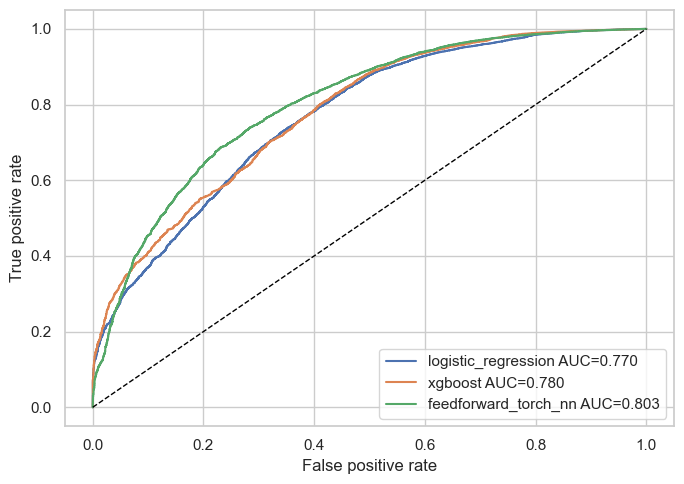

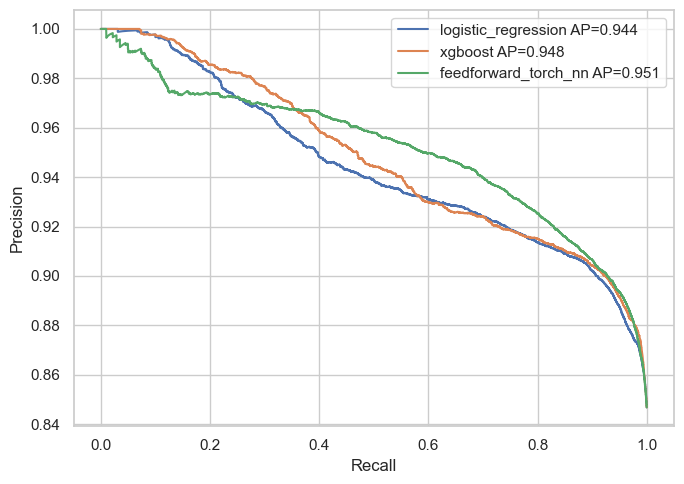

In [35]:
plot_roc_pr_curves(models, X_test, y_test, paths.figures_dir)

## 9. Subgroup Error Disparity Analysis

Algorithmic bias is operationalized as uneven false-positive and false-negative behavior across geopolitical and tactical subgroups. This is model-behavior analysis, not a causal claim about any region or group.

In [36]:
subgroup_columns = ["region_txt", "country_txt", "attacktype1_txt", "targtype1_txt", "weaptype1_txt"]
subgroup_frames = []
for name, model in models.items():
    subgroup_frames.append(subgroup_error_analysis(name, model, X_test, y_test, subgroup_columns, threshold=0.50))
subgroup_df = pd.concat(subgroup_frames, ignore_index=True)
save_table(subgroup_df, paths.tables_dir / "subgroup_error_analysis.csv")

disparity_rows = []
large_groups = subgroup_df[subgroup_df.n >= 200]
for (model_name, subgroup_column), g in large_groups.groupby(["model", "subgroup_column"]):
    disparity_rows.append({
        "model": model_name,
        "subgroup_column": subgroup_column,
        "n_groups": g.group.nunique(),
        "false_positive_rate_gap": g.false_positive_rate.max() - g.false_positive_rate.min(),
        "false_negative_rate_gap": g.false_negative_rate.max() - g.false_negative_rate.min(),
    })
disparity_summary_df = pd.DataFrame(disparity_rows)
save_table(disparity_summary_df, paths.tables_dir / "proposal_subgroup_disparity_summary.csv")

display(subgroup_df.sort_values("false_negative_rate", ascending=False).head(15))
display(disparity_summary_df.sort_values("false_negative_rate_gap", ascending=False))

,model,subgroup_column,group,n,base_success_rate,false_positive_rate,false_negative_rate,tp,fp,tn,fn
162,xgboost,targtype1_txt,Unknown,1438,0.321280,0.000000,1.000000,0,0,976,462
76,logistic_regression,targtype1_txt,Unknown,1438,0.321280,0.000000,1.000000,0,0,976,462
248,feedforward_torch_nn,targtype1_txt,Unknown,1438,0.321280,0.010246,0.991342,4,10,966,458
138,xgboost,attacktype1_txt,Assassination,2615,0.635564,0.008395,0.941637,97,8,945,1565
224,feedforward_torch_nn,attacktype1_txt,Assassination,2615,0.635564,0.011542,0.941637,97,11,942,1565
171,xgboost,weaptype1_txt,Vehicle (not to include vehicle-borne explosiv...,55,0.600000,0.000000,0.939394,2,0,22,31
25,logistic_regression,country_txt,Israel,296,0.706081,0.034483,0.928230,15,3,84,194
52,logistic_regression,attacktype1_txt,Assassination,2615,0.635564,0.020986,0.887485,187,20,933,1475
48,logistic_regression,country_txt,United States,277,0.815884,0.000000,0.880531,27,0,51,199
0,logistic_regression,region_txt,East Asia,50,0.760000,0.000000,0.868421,5,0,12,33


,model,subgroup_column,n_groups,false_positive_rate_gap,false_negative_rate_gap
10,xgboost,attacktype1_txt,7,0.945839,0.931372
6,logistic_regression,country_txt,25,0.931034,0.928230
3,feedforward_torch_nn,targtype1_txt,15,0.510881,0.911481
13,xgboost,targtype1_txt,15,0.775414,0.902778
8,logistic_regression,targtype1_txt,15,0.714286,0.883269
0,feedforward_torch_nn,attacktype1_txt,7,0.473943,0.876710
5,logistic_regression,attacktype1_txt,7,0.775352,0.843439
1,feedforward_torch_nn,country_txt,25,0.919270,0.833958
11,xgboost,country_txt,25,0.932680,0.801502
7,logistic_regression,region_txt,7,0.574887,0.706454


## 10. Interpretability: Logistic Coefficients and XGBoost Feature Importance / SHAP

Logistic coefficients show the linear baseline's global assumptions. XGBoost feature importance or SHAP summarizes nonlinear tree reliance on transformed features.

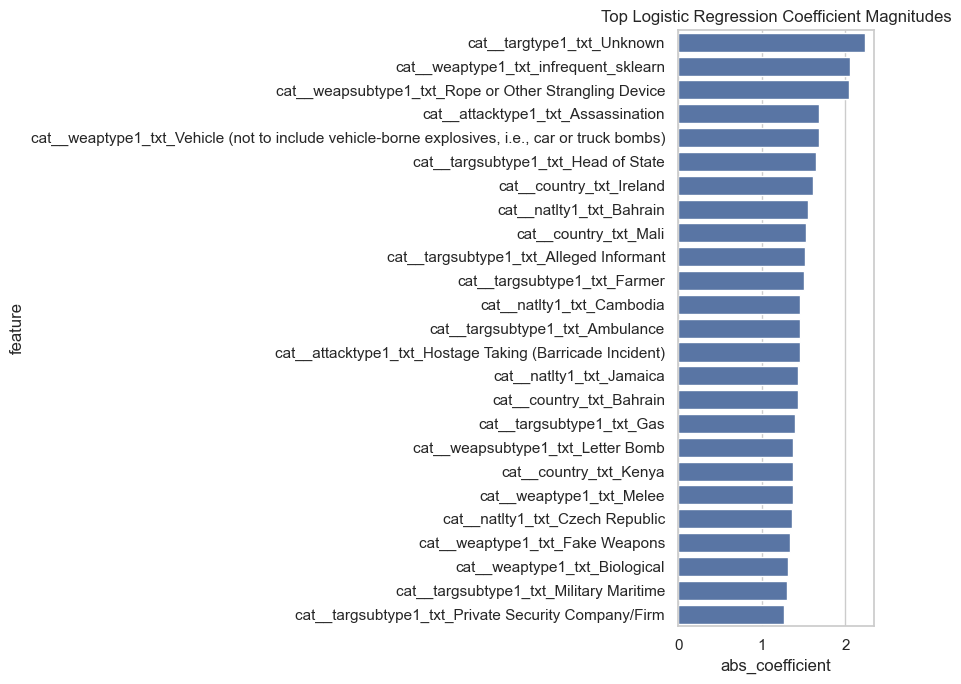

,feature,coefficient,abs_coefficient
198,cat__targtype1_txt_Unknown,-2.231155,2.231155
462,cat__weaptype1_txt_infrequent_sklearn,-2.055709,2.055709
484,cat__weapsubtype1_txt_Rope or Other Strangling...,2.044414,2.044414
171,cat__attacktype1_txt_Assassination,-1.685174,1.685174
461,cat__weaptype1_txt_Vehicle (not to include veh...,1.683652,1.683652
229,cat__targsubtype1_txt_Head of State,-1.647269,1.647269
85,cat__country_txt_Ireland,-1.611515,1.611515
319,cat__natlty1_txt_Bahrain,-1.555627,1.555627
106,cat__country_txt_Mali,1.528064,1.528064
205,cat__targsubtype1_txt_Alleged Informant,1.513821,1.513821


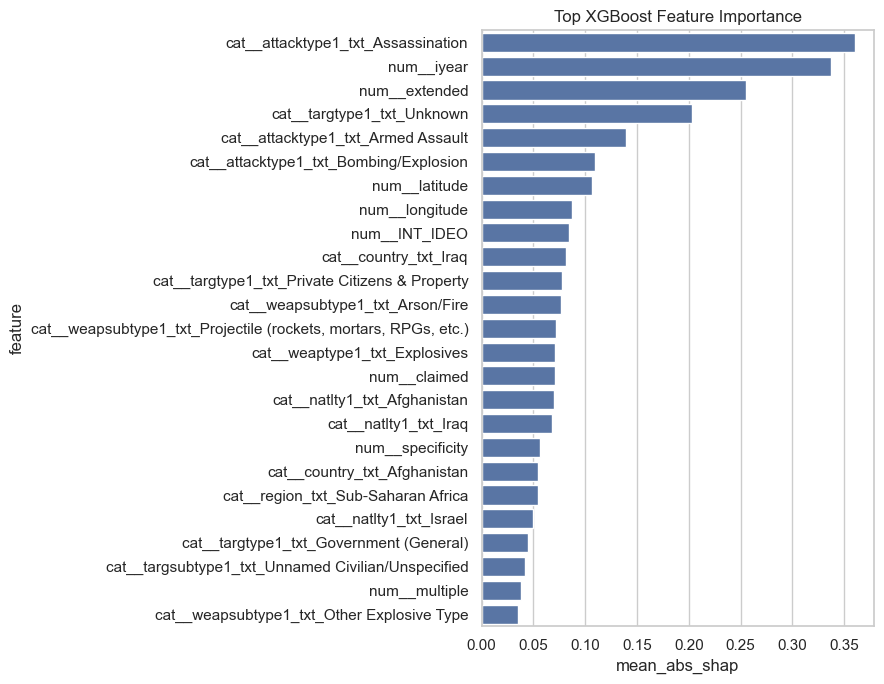

,feature,mean_abs_shap
171,cat__attacktype1_txt_Assassination,0.360656
0,num__iyear,0.337487
3,num__extended,0.255145
198,cat__targtype1_txt_Unknown,0.203464
170,cat__attacktype1_txt_Armed Assault,0.139643
172,cat__attacktype1_txt_Bombing/Explosion,0.109249
4,num__latitude,0.106934
5,num__longitude,0.087652
15,num__INT_IDEO,0.084462
84,cat__country_txt_Iraq,0.082007


In [37]:
def feature_names(pipeline):
    return list(pipeline.named_steps["preprocessor"].get_feature_names_out())

if "logistic_regression" in models:
    lr = models["logistic_regression"]
    lr_importance = pd.DataFrame({
        "feature": feature_names(lr),
        "coefficient": lr.named_steps["model"].coef_.ravel(),
    })
    lr_importance["abs_coefficient"] = lr_importance.coefficient.abs()
    lr_importance = lr_importance.sort_values("abs_coefficient", ascending=False).head(25)
    save_table(lr_importance, paths.tables_dir / "proposal_logistic_coefficients.csv")
    plt.figure(figsize=(9, 7))
    sns.barplot(data=lr_importance, x="abs_coefficient", y="feature")
    plt.title("Top Logistic Regression Coefficient Magnitudes")
    plt.tight_layout()
    plt.savefig(paths.figures_dir / "importance_logistic_regression.png", dpi=180)
    plt.show()
    display(lr_importance)

if "xgboost" in models:
    xgb = models["xgboost"]
    features = feature_names(xgb)
    xgb_model = xgb.named_steps["model"]
    if RUN_SHAP:
        try:
            import shap
            sample = X_test.sample(min(len(X_test), SHAP_SAMPLE_SIZE), random_state=RANDOM_STATE)
            transformed = xgb.named_steps["preprocessor"].transform(sample)
            shap_values = shap.TreeExplainer(xgb_model).shap_values(transformed)
            xgb_importance = pd.DataFrame({"feature": features, "mean_abs_shap": np.abs(shap_values).mean(axis=0)})
            x_axis = "mean_abs_shap"
        except Exception as exc:
            print("SHAP unavailable/failed; using built-in importance:", exc)
            xgb_importance = pd.DataFrame({"feature": features, "importance": xgb_model.feature_importances_})
            x_axis = "importance"
    else:
        xgb_importance = pd.DataFrame({"feature": features, "importance": xgb_model.feature_importances_})
        x_axis = "importance"
    xgb_importance = xgb_importance.sort_values(x_axis, ascending=False).head(25)
    save_table(xgb_importance, paths.tables_dir / "proposal_xgboost_importance.csv")
    plt.figure(figsize=(9, 7))
    sns.barplot(data=xgb_importance, x=x_axis, y="feature")
    plt.title("Top XGBoost Feature Importance")
    plt.tight_layout()
    plt.savefig(paths.figures_dir / "importance_xgboost.png", dpi=180)
    plt.show()
    display(xgb_importance)

## 11. Robustness Checks: Strict Features and Feature-Group Ablations

Strict-feature analysis removes potentially coding-time variables. Feature-group ablations show whether XGBoost depends more on geography, time, or tactical variables.

In [38]:
STRICT_DROP = ["extended", "claimed", "doubtterr"]
FEATURE_GROUPS_TO_DROP = {
    "drop_geography": ["region_txt", "country_txt", "latitude", "longitude", "natlty1_txt"],
    "drop_time": ["iyear", "imonth", "iday"],
    "drop_tactical_attack_target_weapon": ["attacktype1_txt", "targtype1_txt", "targsubtype1_txt", "weaptype1_txt", "weapsubtype1_txt"],
    "drop_uncertainty_claim": ["doubtterr", "guncertain1", "claimed"],
}

def train_xgb_with_drops(label, drop_cols):
    keep_numeric = [c for c in numeric_features if c not in drop_cols]
    keep_categorical = [c for c in categorical_features if c not in drop_cols]
    keep = keep_numeric + keep_categorical
    pos, neg = max(int((y_train == 1).sum()), 1), max(int((y_train == 0).sum()), 1)
    model = Pipeline([
        ("preprocessor", make_preprocessor(keep_numeric, keep_categorical)),
        ("model", XGBClassifier(
            n_estimators=350, max_depth=4, learning_rate=0.05, subsample=0.85,
            colsample_bytree=0.85, objective="binary:logistic", eval_metric="logloss",
            scale_pos_weight=neg / pos, random_state=RANDOM_STATE, n_jobs=-1, tree_method="hist",
        )),
    ])
    model.fit(X_train[keep], y_train)
    rows = []
    for split, Xs, ys in [("validation", X_valid[keep], y_valid), ("test", X_test[keep], y_test)]:
        rows.append(robust_metrics(label, split, ys, predict_proba_positive(model, Xs), 0.50))
    return rows

strict_rows = train_xgb_with_drops("strict_xgboost", STRICT_DROP)
strict_df = pd.DataFrame(strict_rows)
strict_df["dropped_columns"] = ", ".join(STRICT_DROP)
save_table(strict_df, paths.tables_dir / "proposal_strict_feature_audit.csv")

ablation_rows = []
for split, Xs, ys in [("validation", X_valid, y_valid), ("test", X_test, y_test)]:
    ablation_rows.append(robust_metrics("xgboost_full_feature_set", split, ys, predict_proba_positive(models["xgboost"], Xs), 0.50))
for label, drops in FEATURE_GROUPS_TO_DROP.items():
    print("Running ablation:", label)
    ablation_rows.extend(train_xgb_with_drops(f"xgboost_{label}", drops))
ablation_df = pd.DataFrame(ablation_rows)
save_table(ablation_df, paths.tables_dir / "proposal_feature_group_ablation.csv")

display(strict_df)
display(ablation_df.sort_values(["split", "roc_auc"], ascending=[True, False]))

Running ablation: drop_geography
Running ablation: drop_time
Running ablation: drop_tactical_attack_target_weapon
Running ablation: drop_uncertainty_claim


,model,split,roc_auc,average_precision_success,average_precision_failure,brier_score,threshold,accuracy,balanced_accuracy,precision,recall,f1,false_positive_rate,false_negative_rate,tp,fp,tn,fn,mcc,dropped_columns
0,strict_xgboost,validation,0.788013,0.935610,0.562594,0.165376,0.5,0.771805,0.711215,0.904633,0.806271,0.852625,0.383841,0.193729,26769,2822,4530,6432,0.366444,"extended, claimed, doubtterr"
1,strict_xgboost,test,0.772007,0.942951,0.472392,0.164123,0.5,0.781867,0.692207,0.912215,0.821464,0.864464,0.437051,0.178536,22113,2128,2741,4806,0.325376,"extended, claimed, doubtterr"


,model,split,roc_auc,average_precision_success,average_precision_failure,brier_score,threshold,accuracy,balanced_accuracy,precision,recall,f1,false_positive_rate,false_negative_rate,tp,fp,tn,fn,mcc
3,xgboost_drop_geography,test,0.783395,0.948021,0.472746,0.170276,0.5,0.790487,0.688128,0.909554,0.835692,0.871060,0.459437,0.164308,22496,2237,2632,4423,0.326095
1,xgboost_full_feature_set,test,0.779661,0.947605,0.478004,0.162394,0.5,0.781427,0.693966,0.912982,0.820053,0.864026,0.432122,0.179947,22075,2104,2765,4844,0.327432
5,xgboost_drop_time,test,0.778626,0.946331,0.476596,0.145321,0.5,0.815717,0.691164,0.907890,0.870723,0.888918,0.488396,0.129277,23439,2378,2491,3480,0.352540
9,xgboost_drop_uncertainty_claim,test,0.775681,0.946042,0.474321,0.164012,0.5,0.778973,0.694451,0.913490,0.816301,0.862165,0.427398,0.183699,21974,2081,2788,4945,0.326448
7,xgboost_drop_tactical_attack_target_weapon,test,0.648324,0.907804,0.261802,0.229730,0.5,0.629546,0.610430,0.894246,0.637988,0.744688,0.417129,0.362012,17174,2031,2838,9745,0.162654
0,xgboost_full_feature_set,validation,0.796981,0.939900,0.567509,0.161846,0.5,0.774419,0.717312,0.907305,0.806903,0.854164,0.372280,0.193097,26790,2737,4615,6411,0.376334
2,xgboost_drop_geography,validation,0.795908,0.938568,0.566292,0.171105,0.5,0.762311,0.697369,0.899221,0.799253,0.846295,0.404516,0.200747,26536,2974,4378,6665,0.341632
4,xgboost_drop_time,validation,0.792264,0.937094,0.570438,0.146667,0.5,0.809237,0.718350,0.901618,0.860938,0.880809,0.424238,0.139062,28584,3119,4233,4617,0.407323
8,xgboost_drop_uncertainty_claim,validation,0.790276,0.937354,0.564956,0.165599,0.5,0.767514,0.711877,0.905780,0.799163,0.849138,0.375408,0.200837,26533,2760,4592,6668,0.364537
6,xgboost_drop_tactical_attack_target_weapon,validation,0.636072,0.885423,0.297810,0.235429,0.5,0.624023,0.596499,0.866079,0.639680,0.735859,0.446681,0.360320,21238,3284,4068,11963,0.152081


## 12. Bootstrap Confidence Intervals and Calibration

Confidence intervals quantify uncertainty. Calibration curves test whether model scores are meaningful for threshold-based decisions.

,model,metric,point_estimate,ci_lower_95,ci_upper_95
0,logistic_regression,roc_auc,0.769711,0.762802,0.777403
1,logistic_regression,average_precision_success,0.943835,0.941135,0.946281
2,logistic_regression,average_precision_failure,0.455160,0.442472,0.472240
3,logistic_regression,balanced_accuracy,0.692024,0.685245,0.699850
4,logistic_regression,mcc,0.306219,0.294494,0.318639
5,xgboost,roc_auc,0.779661,0.773172,0.786377
6,xgboost,average_precision_success,0.947605,0.945065,0.949993
7,xgboost,average_precision_failure,0.478004,0.463577,0.491051
8,xgboost,balanced_accuracy,0.693966,0.687637,0.700719
9,xgboost,mcc,0.327432,0.316184,0.338097


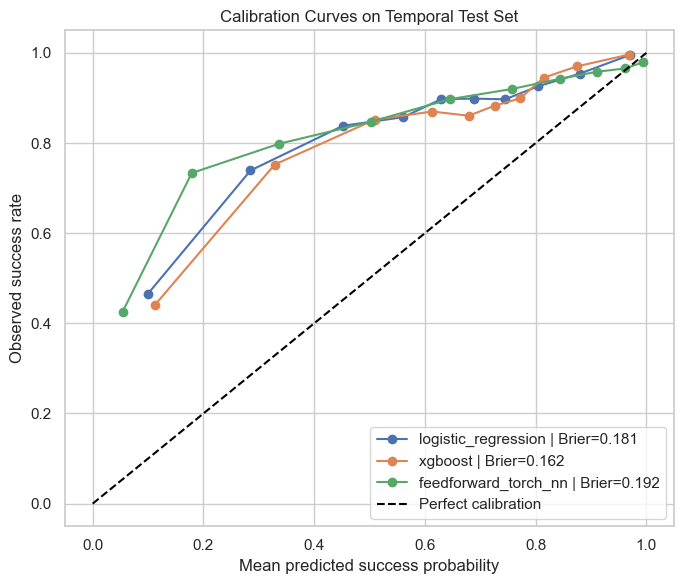

,model,bin,mean_predicted_probability,observed_success_rate,brier_score
0,logistic_regression,1,0.099111,0.464612,0.181485
1,logistic_regression,2,0.285047,0.739226,0.181485
2,logistic_regression,3,0.451882,0.838314,0.181485
3,logistic_regression,4,0.560793,0.857458,0.181485
4,logistic_regression,5,0.629541,0.897452,0.181485
5,logistic_regression,6,0.688388,0.898710,0.181485
6,logistic_regression,7,0.744913,0.897105,0.181485
7,logistic_regression,8,0.804025,0.925763,0.181485
8,logistic_regression,9,0.879750,0.954074,0.181485
9,logistic_regression,10,0.970700,0.995596,0.181485


In [39]:
from sklearn.calibration import calibration_curve

N_BOOTSTRAP = 300
rng = np.random.default_rng(RANDOM_STATE)

def bootstrap_ci(name, y_true, proba, threshold=0.50):
    y_arr, p_arr = np.asarray(y_true), np.asarray(proba)
    rows = []
    for _ in range(N_BOOTSTRAP):
        idx = rng.integers(0, len(y_arr), len(y_arr))
        if len(np.unique(y_arr[idx])) < 2:
            continue
        rows.append(robust_metrics(name, "bootstrap", y_arr[idx], p_arr[idx], threshold))
    boot = pd.DataFrame(rows)
    point = robust_metrics(name, "test", y_arr, p_arr, threshold)
    metrics = ["roc_auc", "average_precision_success", "average_precision_failure", "balanced_accuracy", "mcc"]
    return pd.DataFrame([{
        "model": name,
        "metric": m,
        "point_estimate": point[m],
        "ci_lower_95": boot[m].quantile(0.025),
        "ci_upper_95": boot[m].quantile(0.975),
    } for m in metrics])

ci_df = pd.concat([bootstrap_ci(name, y_test, predict_proba_positive(model, X_test)) for name, model in models.items()], ignore_index=True)
save_table(ci_df, paths.tables_dir / "proposal_bootstrap_confidence_intervals.csv")
display(ci_df)

calibration_rows = []
plt.figure(figsize=(7, 6))
for name, model in models.items():
    proba = predict_proba_positive(model, X_test)
    frac_pos, mean_pred = calibration_curve(y_test, proba, n_bins=10, strategy="quantile")
    brier = brier_score_loss(y_test, proba)
    for i, (mp, fp) in enumerate(zip(mean_pred, frac_pos), 1):
        calibration_rows.append({"model": name, "bin": i, "mean_predicted_probability": mp, "observed_success_rate": fp, "brier_score": brier})
    plt.plot(mean_pred, frac_pos, marker="o", label=f"{name} | Brier={brier:.3f}")
plt.plot([0, 1], [0, 1], "--", color="black", label="Perfect calibration")
plt.xlabel("Mean predicted success probability")
plt.ylabel("Observed success rate")
plt.title("Calibration Curves on Temporal Test Set")
plt.legend()
plt.tight_layout()
plt.savefig(paths.figures_dir / "proposal_calibration_curves.png", dpi=180)
plt.show()
calibration_df = pd.DataFrame(calibration_rows)
save_table(calibration_df, paths.tables_dir / "proposal_calibration_curves.csv")
display(calibration_df)

## 13. Final Manuscript Summary

The notebook saves models, figures, and tables needed for the paper. Use the tables below to write the results section: main metrics, threshold analysis, subgroup disparities, interpretability, ablations, and confidence intervals.

In [40]:
important_tables = [
    "model_metrics.csv",
    "proposal_validation_selected_thresholds.csv",
    "threshold_simulation_results.csv",
    "subgroup_error_analysis.csv",
    "proposal_subgroup_disparity_summary.csv",
    "proposal_xgboost_importance.csv",
    "proposal_logistic_coefficients.csv",
    "proposal_strict_feature_audit.csv",
    "proposal_feature_group_ablation.csv",
    "proposal_bootstrap_confidence_intervals.csv",
    "proposal_calibration_curves.csv",
]
print("Saved models to:", paths.models_dir)
print("Saved figures to:", paths.figures_dir)
print("Saved tables to:", paths.tables_dir)
for table in important_tables:
    print(" -", paths.tables_dir / table)
print("Notebook complete.")

Saved models to: c:\Documents\Compsci\CSELEC2C\Project\models
Saved figures to: c:\Documents\Compsci\CSELEC2C\Project\results\figures
Saved tables to: c:\Documents\Compsci\CSELEC2C\Project\results\tables
 - c:\Documents\Compsci\CSELEC2C\Project\results\tables\model_metrics.csv
 - c:\Documents\Compsci\CSELEC2C\Project\results\tables\proposal_validation_selected_thresholds.csv
 - c:\Documents\Compsci\CSELEC2C\Project\results\tables\threshold_simulation_results.csv
 - c:\Documents\Compsci\CSELEC2C\Project\results\tables\subgroup_error_analysis.csv
 - c:\Documents\Compsci\CSELEC2C\Project\results\tables\proposal_subgroup_disparity_summary.csv
 - c:\Documents\Compsci\CSELEC2C\Project\results\tables\proposal_xgboost_importance.csv
 - c:\Documents\Compsci\CSELEC2C\Project\results\tables\proposal_logistic_coefficients.csv
 - c:\Documents\Compsci\CSELEC2C\Project\results\tables\proposal_strict_feature_audit.csv
 - c:\Documents\Compsci\CSELEC2C\Project\results\tables\proposal_feature_group_ablat